### **Mount to the Drive**

In [8]:
base_dir = '/content/drive/MyDrive/epipolar-geometry-dinov2/epipolar-geometry-dinov2'

In [9]:
from google.colab import drive
drive.mount('/content/drive')

%cd $base_dir

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/epipolar-geometry-dinov2/epipolar-geometry-dinov2


In [10]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

In [11]:
# Input type: BGR
def stereo_img_viewer(left_img, right_img):
  left_img_rgb = cv.cvtColor(left_img, cv.COLOR_BGR2RGB)
  right_img_rgb = cv.cvtColor(right_img, cv.COLOR_BGR2RGB)

  fig, axs = plt.subplots(1, 2, figsize=(12, 3))
  fig.suptitle('Sequence 00 | First Images')

  axs[0].imshow(left_img_rgb)
  axs[0].set_title('image_2')
  axs[1].imshow(right_img_rgb)
  axs[1].set_title('image_3')

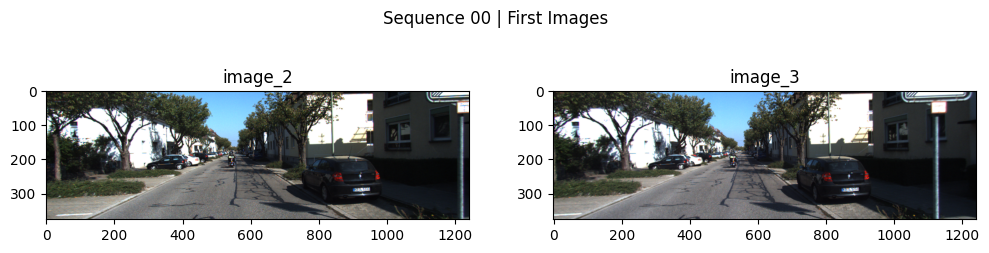

In [12]:
left_img_path = f'{base_dir}/data/kitti_sample/sequences/00/image_2/000000.png'
right_img_path = f'{base_dir}/data/kitti_sample/sequences/00/image_3/000000.png'

left_img = cv.imread(left_img_path)
right_img = cv.imread(right_img_path)

stereo_img_viewer(left_img, right_img)

# **SIFT DESCRIPTORS**

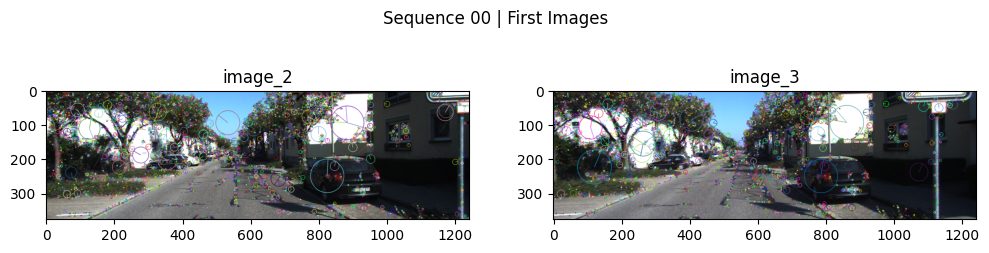

In [13]:
left_img_gray = cv.cvtColor(left_img, cv.COLOR_BGR2GRAY)
right_img_gray = cv.cvtColor(right_img, cv.COLOR_BGR2GRAY)

sift = cv.SIFT_create()

left_img_kps, left_img_des = sift.detectAndCompute(left_img_gray, None)
right_img_kps, right_img_des = sift.detectAndCompute(right_img_gray, None)

left_img_drawn_kps = cv.drawKeypoints(left_img, left_img_kps, None, flags=cv.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
right_img_drawn_kps = cv.drawKeypoints(right_img, right_img_kps, None, flags=cv.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

stereo_img_viewer(left_img_drawn_kps, right_img_drawn_kps)

# **Feature Matcher**

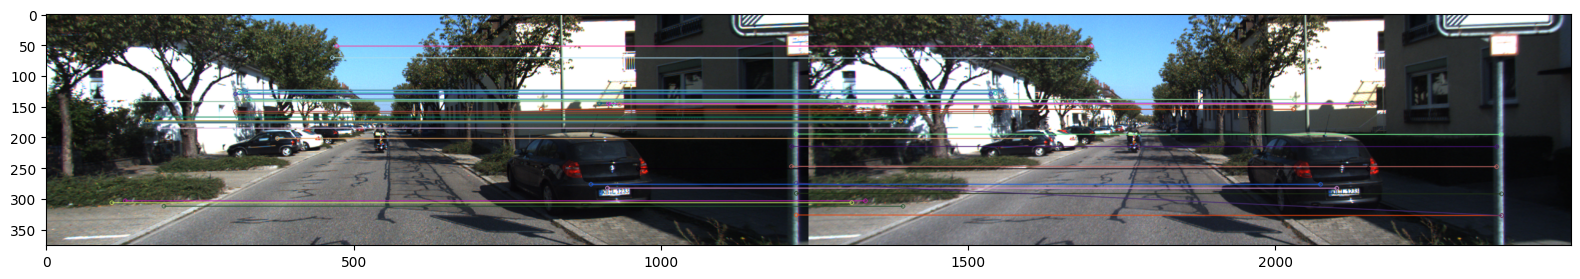

In [14]:
bf_matcher = cv.BFMatcher()
matches = bf_matcher.knnMatch(left_img_des, right_img_des, k=2)

# David Lowe's Ratio Test
good=[]
for best, second in matches:
  if best.distance < (0.75 * second.distance):
    good.append([best])

good = sorted(good, key=lambda x: x[0].distance)
left_img_rgb = cv.cvtColor(left_img, cv.COLOR_BGR2RGB)
right_img_rgb = cv.cvtColor(right_img, cv.COLOR_BGR2RGB)

matchings_visualization = cv.drawMatchesKnn(left_img_rgb, left_img_kps, right_img_rgb, right_img_kps, good[:40], None, flags=2)

plt.figure(figsize=(21,3))
plt.imshow(matchings_visualization)
plt.show()
